In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/2
    print("準備完了！このまま下のセルを実行できます。")

# 2.3 ガウス分布 (The Gaussian Distribution)
本ノートブックでは、連続確率変数のモデル化において中心的な役割を果たす**多変量ガウス分布 (Multivariate Gaussian distribution)** の全貌を深く学びます。

### 本ノートブックの構成:
1. **幾何学的性質とマハラノビス距離**: 固有値分解と等確率密度楕円
2. **条件付きガウス分布と周辺ガウス分布**: 分割精度行列・共分散行列の解析解
3. **線形ガウスモデル (Linear Gaussian Systems)**: ベイズの定理による同時・周辺・事後分布の解析的導出
4. **最尤推定と標本分散のバイアス**: 有限サンプルにおける過小評価の理論とシミュレーション
5. **逐次推定とロビンス・モンロー (Robbins-Monro) アルゴリズム**: 確率的近似法によるオンライン推定
6. **ガウス分布のベイズ推論**: ガウス事前分布（平均）、ガンマ事前分布（精度）、正規ガンマ事前分布（同時）
7. **スチューデントのt分布 (Student's t-distribution)**: 外れ値に対する頑健性 (Robustness)
8. **周期変数とフォン・ミーゼス分布 (The von Mises Distribution)**: 円周上の正規分布

## 2.3.1 ガウス分布の幾何学的性質とマハラノビス距離

$D$ 次元ベクトル $\mathbf{x}$ に対する多変量ガウス分布の確率密度関数は以下で与えられます。

$$ \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right) $$

ここで $\boldsymbol{\mu}$ は $D$ 次元平均ベクトル、$\boldsymbol{\Sigma}$ は $D \times D$ の対称正定値共分散行列です。
マハラノビス距離の二乗 $\Delta^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})$ の等高線は超楕円体を形成します。

## 2.3.2 条件付きガウス分布と周辺ガウス分布

確率変数ベクトルを $\mathbf{x} = (\mathbf{x}_a^T, \mathbf{x}_b^T)^T$ と2分割します。
条件付き分布 $p(\mathbf{x}_a | \mathbf{x}_b)$ および周辺分布 $p(\mathbf{x}_a)$ は以下で与えられます。

$$ \boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a + \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}(\mathbf{x}_b - \boldsymbol{\mu}_b) $$
$$ \boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba} $$
$$ \mathbb{E}[\mathbf{x}_a] = \boldsymbol{\mu}_a, \quad \mathrm{cov}[\mathbf{x}_a] = \boldsymbol{\Sigma}_{aa} $$

Plot saved to: result/fig2_gaussian_condition_marginal.png


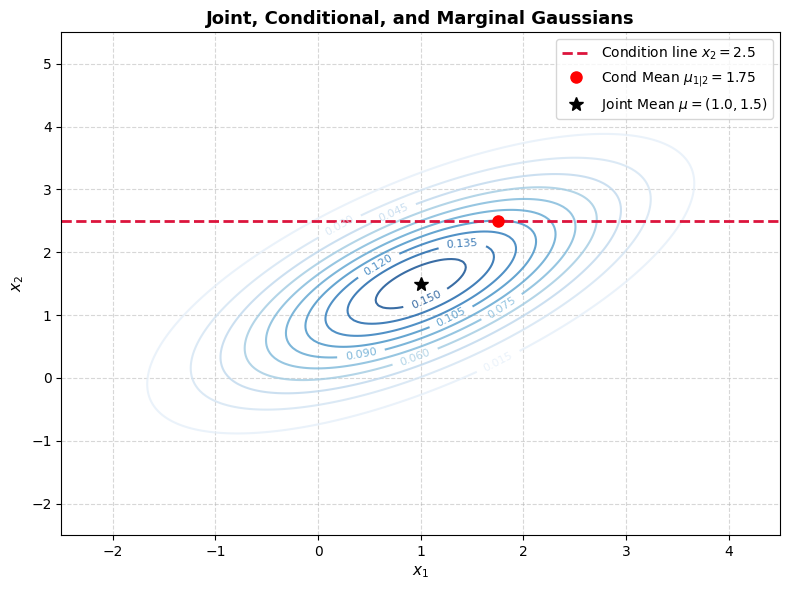

In [1]:
# 条件付き分布と周辺分布の可視化 (PRML Section 2.3.3 - 2.3.4)
import sys, os
sys.path.append(os.path.abspath('../'))
os.makedirs("result", exist_ok=True)
from common.plot_utils import save_plot, setup_style
setup_style()

import numpy as np
import matplotlib.pyplot as plt
from prml.distributions import MultivariateGaussian

mu = np.array([1.0, 1.5])
cov = np.array([[1.5, 0.9], [0.9, 1.2]])
mg = MultivariateGaussian(mean=mu, cov=cov)

# グリッド上の2D同時ガウス密度
x1_grid = np.linspace(-2.5, 4.5, 200)
x2_grid = np.linspace(-2.5, 5.5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
pos = np.dstack((X1, X2))
Z = mg.pdf(pos.reshape(-1, 2)).reshape(X1.shape)

# 条件付け: x2 = 2.5
x2_fixed = 2.5
cond = mg.condition(x_b=[x2_fixed], idx_a=[0], idx_b=[1])
marg = mg.marginalize(idx_a=[0])

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(X1, X2, Z, levels=12, cmap='Blues', alpha=0.8)
ax.clabel(cs, inline=True, fontsize=8)

# 条件付き切断線
ax.axhline(x2_fixed, color='crimson', linestyle='--', lw=2, label=f'Condition line $x_2 = {x2_fixed}$')
ax.plot(cond.mean[0], x2_fixed, 'ro', markersize=8, label=f'Cond Mean $\mu_{{1|2}} = {cond.mean[0]:.2f}$')
ax.plot(mu[0], mu[1], 'k*', markersize=10, label=r'Joint Mean $\mu = (1.0, 1.5)$')

ax.set_title('Joint, Conditional, and Marginal Gaussians', fontsize=13, fontweight='bold')
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot(fig, "result", "fig2_gaussian_condition_marginal.png")
plt.show()

## 2.3.3 線形ガウスモデル (Linear Gaussian Systems)

PRML 式 (2.113) - (2.115) で与えられる線形ガウスモデルを扱います。
$$ p(\mathbf{x}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_x, \boldsymbol{\Sigma}_x) $$
$$ p(\mathbf{y} | \mathbf{x}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\mathbf{x} + \mathbf{b}, \mathbf{L}^{-1}) $$

### 周辺分布 $p(\mathbf{y})$
$$ p(\mathbf{y}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\boldsymbol{\mu}_x + \mathbf{b}, \mathbf{L}^{-1} + \mathbf{A}\boldsymbol{\Sigma}_x\mathbf{A}^T) $$

### 事後分布 $p(\mathbf{x} | \mathbf{y})$
$$ p(\mathbf{x} | \mathbf{y}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\Sigma}_{x|y} \{ \mathbf{A}^T\mathbf{L}(\mathbf{y} - \mathbf{b}) + \boldsymbol{\Sigma}_x^{-1}\boldsymbol{\mu}_x \}, \boldsymbol{\Sigma}_{x|y}) $$
ここで $\boldsymbol{\Sigma}_{x|y} = (\boldsymbol{\Sigma}_x^{-1} + \mathbf{A}^T\mathbf{L}\mathbf{A})^{-1}$ です。

Marginal p(y) Mean: 2.000 (Theoretical: 2.000)
Marginal p(y) Var:  5.300 (Theoretical: 5.300)
Posterior p(x|y=3.0) Mean: 1.566
Posterior p(x|y=3.0) Var:  0.302
Plot saved to: result/fig2_linear_gaussian_system.png


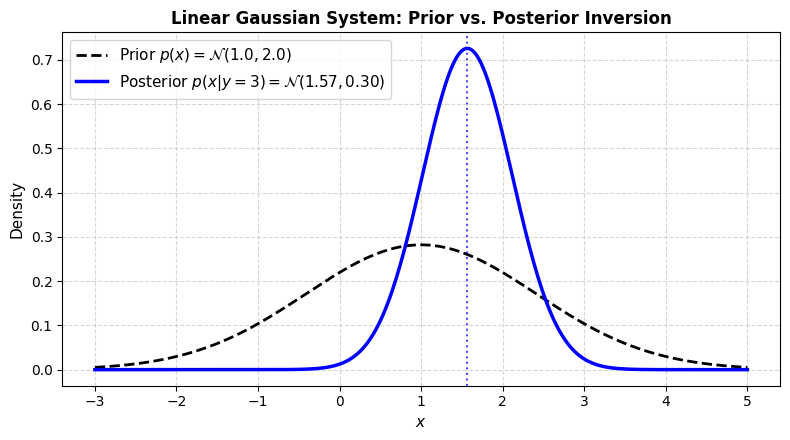

In [2]:
# 線形ガウスモデルの数値検証 (PRML Section 2.3.5)
mu_x = np.array([1.0])
sigma_x = np.array([[2.0]])
A = np.array([[1.5]])
b = np.array([0.5])
L_cov = np.array([[0.8]])

marginal_y, post_solver = MultivariateGaussian.linear_gaussian_system(
    mu_x=mu_x, sigma_x=sigma_x, A=A, b=b, L_cov=L_cov
)

print(f"Marginal p(y) Mean: {marginal_y.mean[0]:.3f} (Theoretical: {1.5*1.0 + 0.5:.3f})")
print(f"Marginal p(y) Var:  {marginal_y.cov[0, 0]:.3f} (Theoretical: {0.8 + 1.5**2 * 2.0:.3f})")

post_x = post_solver([3.0])
print(f"Posterior p(x|y=3.0) Mean: {post_x.mean[0]:.3f}")
print(f"Posterior p(x|y=3.0) Var:  {post_x.cov[0, 0]:.3f}")

# プロット
x_axis = np.linspace(-3, 5, 300)
from prml.distributions import Gaussian1D
prior_pdf = Gaussian1D(mu=mu_x[0], var=sigma_x[0, 0]).pdf(x_axis)
post_pdf = Gaussian1D(mu=post_x.mean[0], var=post_x.cov[0, 0]).pdf(x_axis)

fig = plt.figure(figsize=(8, 4.5))
plt.plot(x_axis, prior_pdf, 'k--', lw=2, label=f'Prior $p(x) = \mathcal{{N}}({mu_x[0]}, {sigma_x[0,0]})$')
plt.plot(x_axis, post_pdf, 'b-', lw=2.5, label=f'Posterior $p(x|y=3) = \mathcal{{N}}({post_x.mean[0]:.2f}, {post_x.cov[0,0]:.2f})$')
plt.axvline(post_x.mean[0], color='blue', linestyle=':', alpha=0.7)
plt.title('Linear Gaussian System: Prior vs. Posterior Inversion', fontsize=12, fontweight='bold')
plt.xlabel('$x$', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_linear_gaussian_system.png")
plt.show()

## 2.3.4 最尤推定における標本分散のバイアス (Bias of Sample Variance)

$N$ 個の独立観測データに対するガウス最尤推定量は以下です。
$$ \mu_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^N x_n, \quad \sigma_{\mathrm{ML}}^2 = \frac{1}{N}\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 $$

期待値:
$$ \mathbb{E}[\mu_{\mathrm{ML}}] = \mu, \quad \mathbb{E}[\sigma_{\mathrm{ML}}^2] = \left( \frac{N - 1}{N} \right) \sigma^2 $$

Plot saved to: result/fig2_sample_var_bias.png


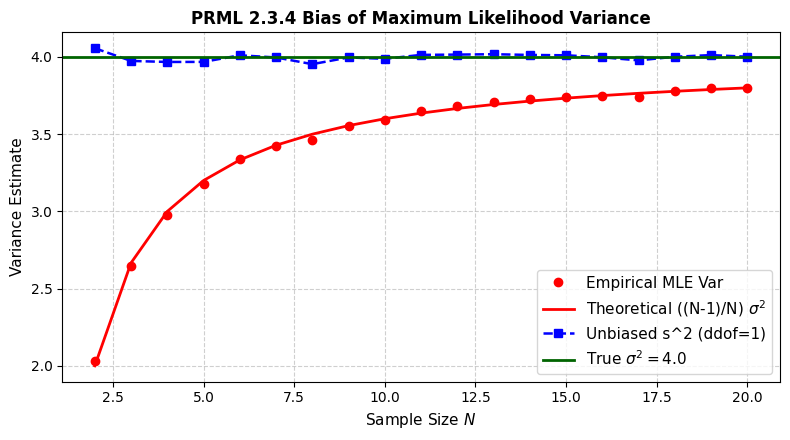

In [3]:
# 標本分散のバイアスのモンテカルロ検証 (PRML Section 2.3.4)
np.random.seed(42)
true_var = 4.0
sample_sizes = np.arange(2, 21)
n_trials = 5000

avg_mle_var = []
avg_unbiased_var = []

for n in sample_sizes:
    samples = np.random.normal(loc=0.0, scale=np.sqrt(true_var), size=(n_trials, n))
    mle_v = np.var(samples, axis=1, ddof=0)
    unb_v = np.var(samples, axis=1, ddof=1)
    avg_mle_var.append(np.mean(mle_v))
    avg_unbiased_var.append(np.mean(unb_v))

theory_mle = [(n - 1) / n * true_var for n in sample_sizes]

fig = plt.figure(figsize=(8, 4.5))
plt.plot(sample_sizes, avg_mle_var, 'ro', label='Empirical MLE Var')
plt.plot(sample_sizes, theory_mle, 'r-', lw=2, label=r'Theoretical ((N-1)/N) $\sigma^2$')
plt.plot(sample_sizes, avg_unbiased_var, 'bs--', lw=1.8, label='Unbiased s^2 (ddof=1)')
plt.axhline(true_var, color='darkgreen', linestyle='-', lw=2, label=f'True $\sigma^2 = {true_var}$')
plt.title('PRML 2.3.4 Bias of Maximum Likelihood Variance', fontsize=12, fontweight='bold')
plt.xlabel('Sample Size $N$', fontsize=11)
plt.ylabel('Variance Estimate', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_sample_var_bias.png")
plt.show()

## 2.3.5 逐次推定とロビンス・モンロー (Robbins-Monro) アルゴリズム

根探索問題 $f(	heta) = \mathbb{E}[z|	heta] = 0$ に対し、**ロビンス・モンローアルゴリズム**は以下の逐次更新を行います。
$$ 	heta^{(N)} = 	heta^{(N-1)} - a_{N-1} z(x_N, 	heta^{(N-1)}) $$
$\sum_{N=1}^\infty a_N = \infty$ かつ $\sum_{N=1}^\infty a_N^2 < \infty$ を満たすステップ幅列 $a_N$（例: $a/N$）により確率収束が保証されます。

Plot saved to: result/fig2_robbins_monro.png


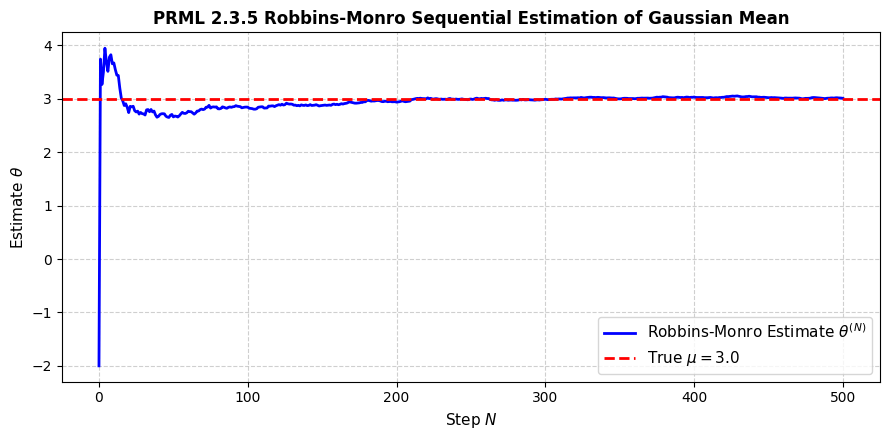

In [4]:
# ロビンス・モンローによる逐次平均推定のシミュレーション (PRML Section 2.3.5)
from prml.distributions import RobbinsMonro

np.random.seed(42)
mu_true = 3.0
X_seq = np.random.normal(loc=mu_true, scale=1.5, size=500)

rm = RobbinsMonro(a_coeff=1.0)
final_mu, history = rm.estimate_mean(X_seq, init_mu=-2.0)

fig = plt.figure(figsize=(9, 4.5))
plt.plot(history, 'b-', lw=2, label=r'Robbins-Monro Estimate $\theta^{(N)}$')
plt.axhline(mu_true, color='red', linestyle='--', lw=2, label=f'True $\mu = {mu_true}$')
plt.title('PRML 2.3.5 Robbins-Monro Sequential Estimation of Gaussian Mean', fontsize=12, fontweight='bold')
plt.xlabel('Step $N$', fontsize=11)
plt.ylabel(r'Estimate $\theta$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_robbins_monro.png")
plt.show()

## 2.3.6 スチューデントのt分布と外れ値に対する頑健性

スチューデントのt分布は、ガウス分布の精度をガンマ分布で周辺化した混合分布です。
自由度 $
u$ が小さいとき裾が重く (heavy tails)、外れ値（outliers）が存在しても中心パラメータの推定が引きずられない頑健性 (Robustness) を持ちます。

Plot saved to: result/fig2_robust_student_t.png


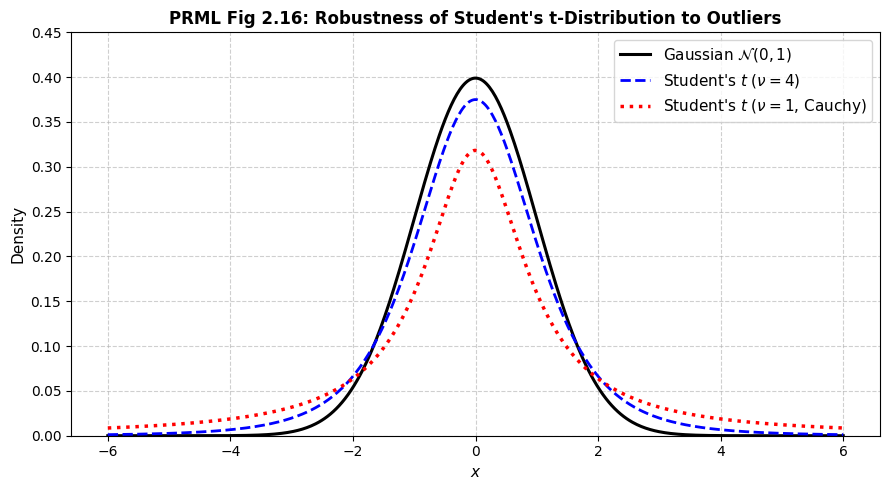

In [5]:
# 外れ値に対するガウス分布 vs スチューデントt分布の頑健性比較 (PRML Fig 2.16)
from prml.distributions import Gaussian1D, StudentsTDistribution

x_axis = np.linspace(-6, 6, 500)
g = Gaussian1D(mu=0.0, var=1.0)
st1 = StudentsTDistribution(mu=0.0, lam=1.0, nu=1.0)
st4 = StudentsTDistribution(mu=0.0, lam=1.0, nu=4.0)

fig = plt.figure(figsize=(9, 5))
plt.plot(x_axis, g.pdf(x_axis), 'k-', lw=2.2, label=r'Gaussian $\mathcal{N}(0, 1)$')
plt.plot(x_axis, [st4.pdf(x) for x in x_axis], 'b--', lw=2, label=r"Student's $t$ ($\nu=4$)")
plt.plot(x_axis, [st1.pdf(x) for x in x_axis], 'r:', lw=2.5, label=r"Student's $t$ ($\nu=1$, Cauchy)")
plt.title("PRML Fig 2.16: Robustness of Student's t-Distribution to Outliers", fontsize=12, fontweight='bold')
plt.xlabel('$x$', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.ylim(0, 0.45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_robust_student_t.png")
plt.show()

## 2.3.7 周期変数とフォン・ミーゼス分布 (The von Mises Distribution)

円周上の正規分布として**フォン・ミーゼス分布**が定義されます。
$$ p(	heta | \mu, \kappa) = \frac{1}{2\pi I_0(\kappa)} \exp (\kappa \cos(	heta - \mu)) $$
ここで $I_0(\kappa)$ は0次の第1種変形ベッセル関数です。

Plot saved to: result/fig2_von_mises.png


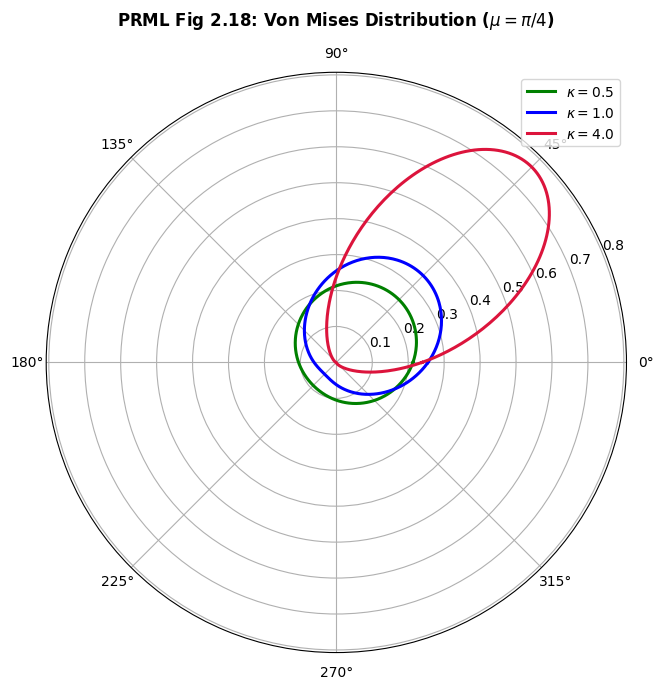

In [6]:
# フォン・ミーゼス分布の極座標プロット (PRML Fig 2.18)
from prml.distributions import VonMisesDistribution

thetas = np.linspace(0, 2 * np.pi, 500)
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))

kappas = [0.5, 1.0, 4.0]
colors = ['green', 'blue', 'crimson']

for kappa, c in zip(kappas, colors):
    vm = VonMisesDistribution(mu=np.pi / 4.0, kappa=kappa)
    r_vals = [vm.pdf(th) for th in thetas]
    ax.plot(thetas, r_vals, color=c, lw=2.2, label=f'$\kappa = {kappa}$')

ax.set_title(r'PRML Fig 2.18: Von Mises Distribution ($\mu = \pi/4$)', fontsize=12, fontweight='bold', pad=15)
ax.legend(loc='upper right')
plt.tight_layout()
save_plot(fig, "result", "fig2_von_mises.png")
plt.show()

## まとめ
1. 多変量ガウス分布は条件付き分布および周辺分布のいずれもが閉じたガウス分布となる極めて有用な数学的性質を持つ。
2. 線形ガウスモデルにより、観測の反転問題（ベイズ推論）が解析的な行列演算のみで高速に実行できる。
3. 最尤推定の標本分散には $\frac{N-1}{N}$ のバイアスが存在し、ベイズ的アプローチや不偏推定量が不可欠となる。
4. 外れ値に対してはスチューデントt分布、周期データに対してはフォン・ミーゼス分布を用いることで、ガウス分布の弱点を克服できる。